In [ ]:
import sys
import os

sys.path.insert(0, os.path.abspath("../"))

In [ ]:
import photospline

from icecube import dataio, icetray, dataclasses, simclasses
import numpy.random as random
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt
from scripts.python.SplineEval import evalLogPdf, evalPdf
from matplotlib.colors import LogNorm

In [ ]:
file_500 = dataio.I3File('../nue_data/gen_500.i3.zst')
file_012 = dataio.I3File('../nue_data/gen_012.i3.zst')
gcd = dataio.I3File('../gcdfile/PONE_800mGrid.i3.gz')

iter = 0
for frame in file_500:
    if iter == 17:
        frame18 = frame
    if iter == 26:
        frame27 = frame

    if iter == 92:
        frame93 = frame
    if iter == 127:
        frame128 = frame
    
    iter += 1
iter = 0
for frame in file_012:
    if iter == 69:
        frame70 = frame
    iter += 1
for frame in gcd:
    gcdframe = frame
    break

In [5]:
splinefit_3d = photospline.SplineTable('../fits/splinelog_3D.fits')

In [6]:
print(splinefit_3d.extents[2][0], splinefit_3d.extents[2][1])

-30.726762008826114 1627.6756954685331


In [7]:
print(min(splinefit_3d.knots[-1]), max(splinefit_3d.knots[-1]))

-52.90817161588701 2322.11625869322


In [ ]:
# Randomly chosen set of strings. I just ran the random sampler until it looked nice. Feel free to make a more intelligent 
# subselection for future studies
string_subset = np.array([266, 199, 220, 275,  96, 113, 112, 286, 173, 116, 8, 240, 130,
       307, 281, 112, 324, 306, 183, 303, 314, 289,  72, 113, 147, 177,
       160,  57,  54, 142, 291, 204,  75, 215, 179, 143, 315, 201, 182,
        78,  60,   1, 326,  46, 272, 232, 134, 162, 268, 101, 139, 320,
       195,  11,  86, 300,  84,  67, 129,  63, 310,  59, 215, 312, 188,
       138,  71, 120, 139,  12,  26, 117, 129,  40,   6, 156,  79, 132,
       127, 161])

In [ ]:
c = 299792458
n = 1.34


def datacollect(frame):
    dt = []
    t = []
    dphilst = []
    dr = []
    xyz = []

    Epos = frame["I3MCTree"][1].pos
    doms = gcdframe["I3ModuleGeoMap"]
    omkeys = frame["I3Photons"].keys()
    photons = frame["I3Photons"]
    for key in omkeys:
        # Un-comment if you want to use only a string subset
        # if key.string not in string_subset:
        #     continue
        modulekey = dataclasses.ModuleKey(key.string, key.om)
        dompos = doms[modulekey].pos
        for photon in photons[key]:
            photon_pos = dompos + photon.pos
            xyz.append([photon_pos.x, photon_pos.y, photon_pos.z])
            flight = dompos + photon.pos - Epos
            dr.append(flight.magnitude)
            offset = flight.magnitude * n / c
            dt.append(photon.time - offset * 10**9)
            t.append(photon.time)
            phi = photon.dir
            randx, randy, randz = random.uniform(-1, 1, 3)
            x = phi.x
            y = phi.y
            z = phi.z
            dx = x - randx
            dy = y - randy
            dz = z - randz
            dphi = dataclasses.I3Direction(dx, dy, dz)
            dphilst.append(dphi.zenith)
            # Etheta.append(flight.azimuth)
            # Ephi.append(flight.zenith)

    return np.column_stack([xyz, t, dt])

In [ ]:
EventData1 = datacollect(frame18)
EventData2 = datacollect(frame27)
EventData3 = datacollect(frame70)
EventData4 = datacollect(frame93)
EventData5 = datacollect(frame128)


In [ ]:
def displacement_magnitude(pos1: np.array, pos2: np.array) -> float:
    vector = pos1 - pos2
    return np.sqrt(vector[0] ** 2 + vector[1] ** 2 + vector[2] ** 2)

In [ ]:
def Likelihood_3d(coords: np.array, Event: np.array = EventData1):
    L = 0
    # coords should have shape [x,y,z,azimuth,zenith,t]
    # Event has shape [N, 5] cols:(x,y,z,t,dt). We only use the first 4 here

    event_xyz = Event[:, 0:3]
    event_t = Event[:, 3]

    # Calculate Displacement Magnitude
    diff = coords[0:3] - event_xyz
    dr = np.linalg.norm(diff, axis=1)
    # Calculate Time Residual
    dt = abs(coords[5] - event_t) - (1.34 * dr / c * 1e9)

    # Construct Electron direction unit vector from zenith and azimuth
    Ex = np.sin(coords[4]) * np.cos(coords[3])
    Ey = np.sin(coords[4]) * np.sin(coords[3])
    Ez = np.cos(coords[4])

    # Calculate angle between electron travel vector and displacement vector
    Eangle = np.array([Ex, Ey, Ez])
    Ephi = np.arccos(np.dot(diff, Eangle) / dr)

    # Calculate Likelihood from constructed coordinates
    params = np.array([dr, Ephi, dt])
    vals = splinefit_3d.evaluate_simple([params[0], params[1], params[2]])

    # Floor invalid values
    L = np.where(vals == 0, -30, vals)

    # Sum and return -log Likelihood
    return -np.sum(L)

In [ ]:
def Likelihood_3d_calculation(truth, Event) -> None:
    xary = np.linspace(truth[0] - 15, truth[0] + 15, 500)
    yary = np.linspace(truth[1] - 15, truth[1] + 15, 500)
    zary = np.linspace(truth[2] - 15, truth[2] + 15, 500)
    tary = np.linspace(truth[5] - 50, truth[5] + 50, 500)
    phiary = np.linspace((truth[4] - 0.3), (truth[4] + 0.3), 500)
    ThetaAry = np.linspace((truth[3] - 0.3), (truth[3] + 0.3), 500)
    # phiary = np.linspace(0, np.pi, 500)
    # ThetaAry = np.linspace(0, 2*np.pi, 500)

    xplot = []
    yplot = []
    zplot = []
    tplot = []
    phiplot = []
    thetaplot = []
    for i in range(len(xary)):
        xplot.append(
            Likelihood_3d(
                np.array([xary[i], truth[1], truth[2], truth[3], truth[4], truth[5]]),
                Event=Event,
            )
        )
        yplot.append(
            Likelihood_3d(
                np.array([truth[0], yary[i], truth[2], truth[3], truth[4], truth[5]]),
                Event=Event,
            )
        )
        zplot.append(
            Likelihood_3d(
                np.array([truth[0], truth[1], zary[i], truth[3], truth[4], truth[5]]),
                Event=Event,
            )
        )
        tplot.append(
            Likelihood_3d(
                np.array([truth[0], truth[1], truth[2], truth[3], truth[4], tary[i]]),
                Event=Event,
            )
        )
        phiplot.append(
            Likelihood_3d(
                np.array([truth[0], truth[1], truth[2], truth[3], phiary[i], truth[5]]),
                Event=Event,
            )
        )
        thetaplot.append(
            Likelihood_3d(
                np.array(
                    [truth[0], truth[1], truth[2], ThetaAry[i], truth[4], truth[5]]
                ),
                Event=Event,
            )
        )

    return [xplot, yplot, zplot, thetaplot, phiplot, tplot]

In [ ]:
def likelihood_graphs(truth, data, filename: str):
    xary = np.linspace(truth[0] - 15, truth[0] + 15, 500)
    yary = np.linspace(truth[1] - 15, truth[1] + 15, 500)
    zary = np.linspace(truth[2] - 15, truth[2] + 15, 500)
    tary = np.linspace(truth[5] - 50, truth[5] + 50, 500)
    phiary = np.linspace(
        (truth[4] - 0.3) * 360 / (2 * np.pi), (truth[4] + 0.3) * 360 / (2 * np.pi), 500
    )
    ThetaAry = np.linspace(
        (truth[3] - 0.3) * 360 / (2 * np.pi) - 10,
        (truth[3] + 0.3) * 360 / (2 * np.pi),
        500,
    )
    # phiary = np.linspace(0, 180, 500)
    # ThetaAry = np.linspace(0, 360, 500)

    fig, axs = plt.subplots(2, 3, figsize=(12, 10))

    axs[0, 0].plot(xary, data[0])
    axs[0, 0].set_title("Likelihood Evolution in X")
    axs[0, 0].set_xlabel("X (m)")
    axs[0, 0].set_ylabel("-ln(L)")
    axs[0, 0].vlines(
        truth[0], min(data[0]), max(data[0]), label="Truth", colors="red", ls="--"
    )
    axs[0, 0].grid()
    axs[0, 0].set_ylim(min(data[0]) - 10, min(data[0]) + 50)
    axs[0, 0].set_xlim(truth[0] - 10, truth[0] + 10)
    # #axs[0,0].set_yscale('log')
    axs[0, 0].legend()

    axs[0, 1].plot(yary, data[1])
    axs[0, 1].set_title("Likelihood Evolution in Y")
    axs[0, 1].set_xlabel("Y (m)")
    axs[0, 1].set_ylabel("-ln(L)")
    axs[0, 1].grid()
    axs[0, 1].set_ylim(min(data[1]) - 10, min(data[1]) + 70)
    axs[0, 1].set_xlim(truth[1] - 10, truth[1] + 10)
    # #axs[0,1].set_yscale('log')
    axs[0, 1].vlines(
        truth[1], min(data[1]), max(data[1]), label="Truth", colors="red", ls="--"
    )
    axs[0, 1].legend()

    axs[1, 0].plot(zary, data[2])
    axs[1, 0].set_title("Likelihood Evolution in Z")
    axs[1, 0].set_xlabel("Z (m)")
    axs[1, 0].set_ylabel("-ln(L)")
    axs[1, 0].set_ylim(min(data[2]) - 10, min(data[2]) + 50)
    axs[1, 0].set_xlim(truth[2] - 10, truth[2] + 10)
    # #axs[1,0].set_yscale('log')
    axs[1, 0].vlines(
        truth[2], min(data[2]), max(data[2]), label="Truth", colors="red", ls="--"
    )
    axs[1, 0].grid()
    axs[1, 0].legend()

    axs[1, 1].plot(tary, data[5])
    axs[1, 1].set_title("Likelihood Evolution in t")
    axs[1, 1].set_xlabel("t (ns)")
    axs[1, 1].set_ylabel("-ln(L)")
    axs[1, 1].set_xlim(truth[5] - 10, truth[5] + 10)
    axs[1, 1].set_ylim(min(data[5]) - 50, min(data[5]) + 100)
    # #axs[1,1].set_yscale('log')
    axs[1, 1].vlines(
        truth[5], min(data[5]), max(data[5]), label="Truth", colors="red", ls="--"
    )
    axs[1, 1].grid()
    axs[1, 1].legend()

    axs[1, 2].plot(ThetaAry, data[3])
    axs[1, 2].set_title("Likelihood Evolution in Azimuth")
    axs[1, 2].set_xlabel("Azimuth (deg)")
    axs[1, 2].set_ylabel("-ln(L)")
    axs[1, 2].vlines(
        truth[3] * 360 / (2 * np.pi),
        min(data[3]),
        max(data[3]),
        label="Truth",
        colors="red",
        ls="--",
    )
    axs[1, 2].grid()
    axs[1, 2].set_ylim(min(data[3]) - 10, min(data[3]) + 40)
    axs[1, 2].set_xlim(
        truth[3] * 360 / (2 * np.pi) - 0.3 * 360 / (2 * np.pi),
        truth[3] * 360 / (2 * np.pi) + 0.3 * 360 / (2 * np.pi),
    )
    # axs[1,2].set_yscale('log')
    axs[1, 2].legend()

    axs[0, 2].plot(phiary, data[4])
    axs[0, 2].set_title("Likelihood Evolution in Zenith")
    axs[0, 2].set_xlabel("Zenith (deg)")
    axs[0, 2].set_ylabel("-ln(L)")
    axs[0, 2].vlines(
        truth[4] * 360 / (2 * np.pi),
        min(data[4]),
        max(data[4]),
        label="Truth",
        colors="red",
        ls="--",
    )
    axs[0, 2].grid()
    axs[0, 2].set_ylim(min(data[4]) - 10, min(data[4]) + 40)
    axs[0, 2].set_xlim(
        truth[4] * 360 / (2 * np.pi) - 0.05 * 360 / (2 * np.pi),
        truth[4] * 360 / (2 * np.pi) + 0.05 * 360 / (2 * np.pi),
    )
    # # axs[0,2].set_yscale('log')
    axs[0, 2].legend()

    fig.tight_layout()
    fig.savefig(f"../plots/{filename}.png")

In [17]:
print(frame18["I3MCTree"][1])

[ I3Particle MajorID : 15941211553967342775
             MinorID : 614
              Zenith : 1.12255
             Azimuth : 5.03732
                   X : 2.86453
                   Y : 216.537
                   Z : 254.435
                Time : 0
              Energy : 1847.28
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


In [15]:
likelihood_data = Likelihood_3d_calculation(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), EventData1)

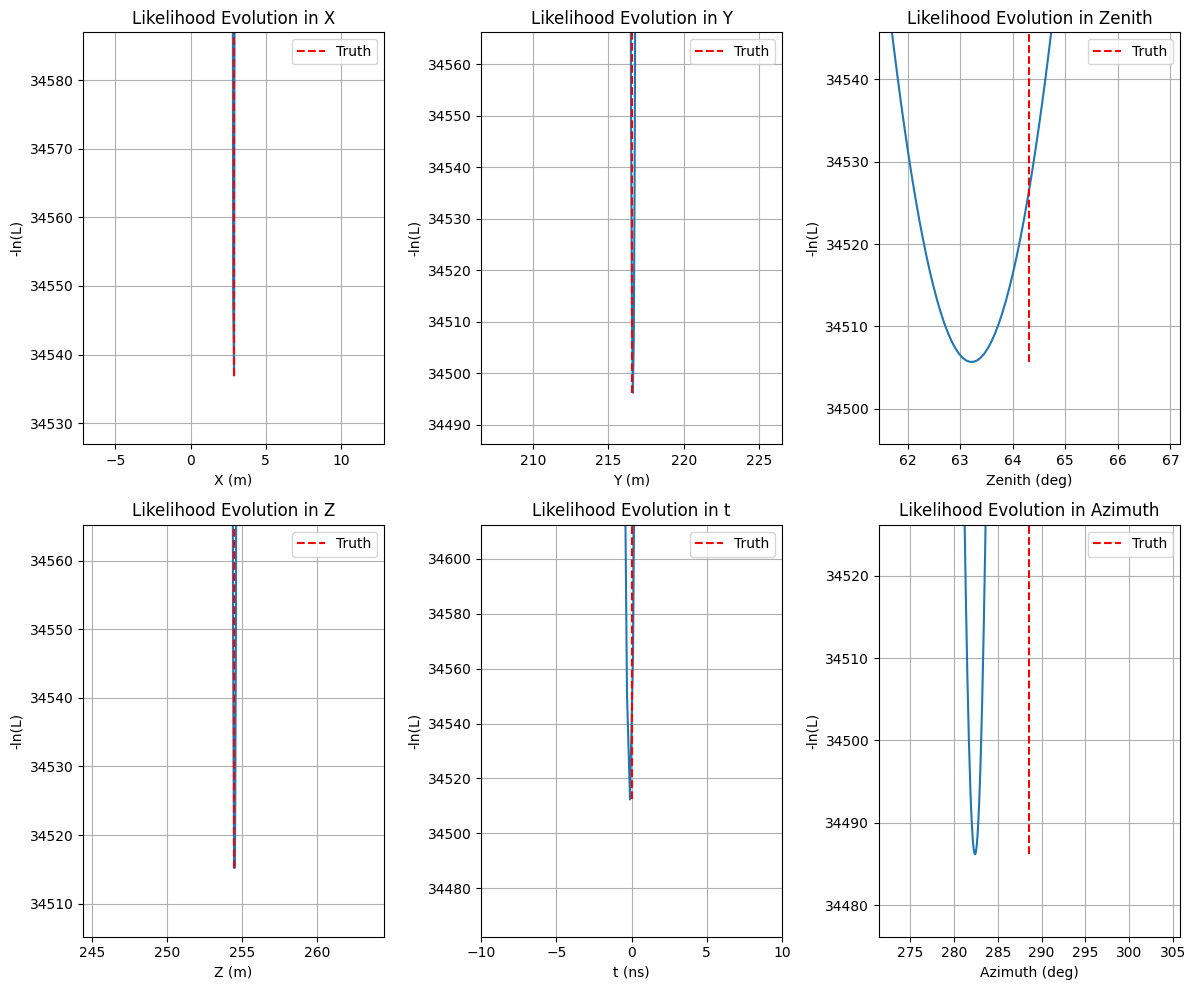

In [ ]:
likelihood_graphs(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), likelihood_data, 'likelihood_evo_test')


In [ ]:
def minimizer(guess, event, function=Likelihood_3d):
    # Guess should be xyzt
    minimized = optimize.minimize(function, 
                                  x0=guess,
                                  args=(event),  
                                  method='Nelder-Mead', 
                                  tol=1e-3)
    return minimized

In [ ]:
minimizer(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), EventData1)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 136.98073601722717
             x: [ 3.420e+00  2.155e+02  2.549e+02  5.367e+00  1.146e+00
                  3.699e-04]
           nit: 222
          nfev: 383
 final_simplex: (array([[ 3.420e+00,  2.155e+02, ...,  1.146e+00,
                         3.699e-04],
                       [ 3.419e+00,  2.155e+02, ...,  1.145e+00,
                         3.694e-04],
                       ...,
                       [ 3.420e+00,  2.155e+02, ...,  1.146e+00,
                         3.695e-04],
                       [ 3.420e+00,  2.155e+02, ...,  1.146e+00,
                         3.700e-04]]), array([ 1.370e+02,  1.370e+02,  1.370e+02,  1.370e+02,
                        1.370e+02,  1.370e+02,  1.370e+02]))

In [ ]:
print(2*(Likelihood_3d(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), EventData1) - Likelihood_3d(np.array([3.420e+00, 2.155e+02, 2.549e+02, 5.367e+00, 1.146e+00, 3.699e-04]), EventData1)))


10.489108085632324


In [ ]:
tgrid = np.linspace(min(splinefit_3d.knots[-1]), max(splinefit_3d.knots[-1]), 1000)
dist_for_pdf = 20.0
phiE_for_pdf = 0.3
pdf = np.exp(splinefit_3d.evaluate_simple([dist_for_pdf, phiE_for_pdf, tgrid]))


2.8312615772301232e-14 1.0


In [ ]:
space_angle_ary = np.array([])
energy_ary = np.array([])
for i in range(501):
    if i < 10:
        runnumber = '00' + str(i)
    elif i < 100:
        runnumber = '0' + str(i)
    else:
        runnumber = str(i)
    if os.path.isfile(f'/mnt/scratch/dillonb5/resolutions_80str/resolution_{runnumber}.npy'):
        #print(runnumber)
        ary = np.load(f'/mnt/scratch/dillonb5/resolutions_80str/resolution_{runnumber}.npy')
    
        if ary.shape == (0,):
            continue
       

        # zenith_ary = np.concatenate((zenith_ary, ary[:,0]))
        # azimuth_ary = np.concatenate((azimuth_ary, ary[:,1]))
        space_angle_ary = np.concatenate((space_angle_ary, ary[:,0]))
        energy_ary = np.concatenate((energy_ary, ary[:,1]))


In [ ]:
len(space_angle_ary)

14566

In [ ]:
space_angle_ary = space_angle_ary*360/(2*np.pi)

In [ ]:
space_angle_ary

array([42.2152582 ,  7.83137182, 38.40023154, ...,  1.57285607,
       10.79123599, 31.01457916])

In [ ]:
count=0
for val in space_angle_ary:
    if not np.isnan(val):
        count+=1
print(count)

14566


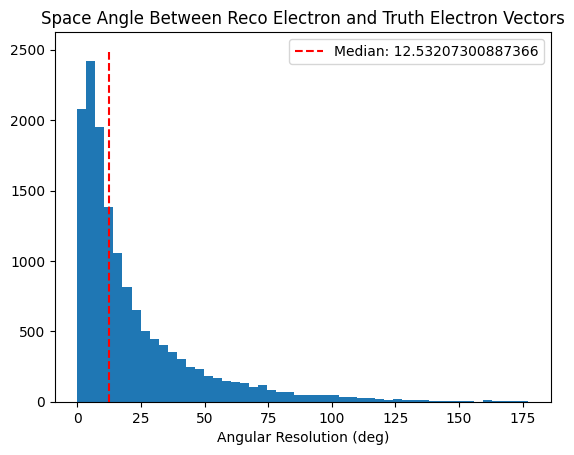

In [ ]:
plt.hist(space_angle_ary, 50)
plt.vlines(np.median(space_angle_ary), 0, 2500, colors='red', ls='--', label=f'Median: {np.median(space_angle_ary)}')
plt.title('Space Angle Between Reco Electron and Truth Electron Vectors')
plt.xlabel('Angular Resolution (deg)')
plt.legend()
plt.savefig(
    '/mnt/home/dillonb5/cascades/plots/angular_res_v1.png'
)

In [ ]:
hist, edges = np.histogram(energy_ary, bins=np.logspace(2, 6, 17))
print(hist)
print(edges)

[4487 3070 2144 1362  989  682  502  356  272  186  135  112   86   89
   64   30]
[1.00000000e+02 1.77827941e+02 3.16227766e+02 5.62341325e+02
 1.00000000e+03 1.77827941e+03 3.16227766e+03 5.62341325e+03
 1.00000000e+04 1.77827941e+04 3.16227766e+04 5.62341325e+04
 1.00000000e+05 1.77827941e+05 3.16227766e+05 5.62341325e+05
 1.00000000e+06]


In [ ]:
def truncate(f, n):
        '''Truncates/pads a float f to n decimal places without rounding'''
        s = '{}'.format(f)
        if 'e' in s or 'E' in s:
                return '{0:.{1}f}'.format(f, n)
        i, p, d = s.partition('.')
        return '.'.join([i, (d+'0'*n)[:n]])

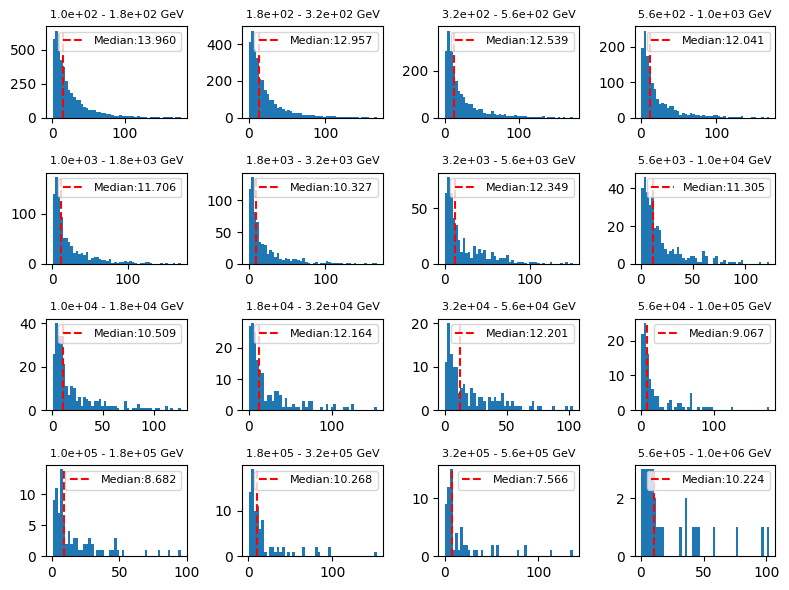

In [ ]:
fig, axs = plt.subplots(4,4, figsize = (8,6))
ct = 0
for i in range(len(axs)):
    for j in range(len(axs[i])):
        bin_mask = (energy_ary >= edges[ct]) & (energy_ary < edges[ct + 1])
        bin_res = space_angle_ary[bin_mask]
        counts, _ = np.histogram(bin_res, bins=50)
        axs[i,j].hist(bin_res, bins=50)
        axs[i,j].set_title(f'{edges[ct]:.1e} - {edges[ct+1]:.1e} GeV', fontsize=8)
        axs[i,j].vlines(np.median(bin_res), 0, max(counts), colors='red', ls='--', label=f'Median:{truncate(np.median(bin_res),3)}')
        #axs[i,j].set_xlabel('Angular Resolution (deg)', fontsize=8)
        axs[i,j].legend(fontsize=8)
        
        ct += 1

fig.tight_layout()
plt.savefig('/mnt/home/dillonb5/cascades/plots/angular_res_energy_binned.png')



In [ ]:
splinefit_3d.extents

((2.0920000317428116, 279.13374889976023),
 (0.0, 3.141592653589793),
 (-30.726762008826114, 1627.6756954685331))

In [ ]:
def cdf(coords, Event):
    t = np.linspace(splinefit_3d.extents[2][0], splinefit_3d.extents[2][1], 2500)
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        diff = coords[0:3] - np.array(event[0:3])

        Ex = np.sin(coords[4])*np.cos(coords[3])
        Ey = np.sin(coords[4])*np.sin(coords[3])
        Ez = np.cos(coords[4])


        # Calculate angle between electron travel vector and displacement vector
        Eangle = np.array([Ex, Ey, Ez])
        Ephi = np.arccos(np.dot(diff, Eangle) / dr)
        
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        #pdf = evalPdf(splinefit_3d, dr, Ephi, t)
        pdf = np.exp(splinefit_3d.evaluate_simple([dr, Ephi, t]))
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])/np.sum(pdf)
        pvalues.append(cdf)

    plt.hist(pvalues, bins=np.linspace(min(pvalues),max(pvalues),50))
    plt.xlabel('CDF Value')
    plt.ylabel('Hits')
    plt.title('3D CDF Distribution')

In [ ]:
def cdf_color_plt(coords, Event):
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        diff = coords[0:3] - np.array(event[0:3])

        Ex = np.sin(coords[4])*np.cos(coords[3])
        Ey = np.sin(coords[4])*np.sin(coords[3])
        Ez = np.cos(coords[4])


        # Calculate angle between electron travel vector and displacement vector
        Eangle = np.array([Ex, Ey, Ez])
        Ephi = np.arccos(np.dot(diff, Eangle) / dr)
        
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        pdf = np.exp(splinefit_3d.evaluate_simple([dr,Ephi, t]))
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])/np.sum(pdf)
        pvalues.append((cdf, Ephi))
    twoDary = np.array(pvalues)
    #print(twoDary)
    hist, edges = np.histogramdd(twoDary, bins=20)
    print(twoDary)
    
    fig, ax = plt.subplots()
    plot = ax.imshow(
        hist.T,                    # Transpose so axis 0 = x, axis 1 = y
        origin='lower',            # Put (0,0) at bottom-left, not top-left
        aspect='auto',
        norm=LogNorm(vmin=1, vmax=hist.max()),             # Don't force square pixels
        extent=[                   # Map pixel coords to data coords
            edges[0][0], edges[0][-1],   # x: cdf axis range
            edges[1][0], edges[1][-1]    # y: dr axis range
        ]
    )
    cbar = ax.figure.colorbar(plot, ax=ax, )
    cbar.ax.set_ylabel('Bin counts', rotation=-90, va="bottom")
    ax.set_xlabel('CDF')
    ax.set_ylabel('Emission Angle')
    plt.tight_layout()
    plt.show()

In [ ]:
#cdf_color_plt(np.array([632.878,-456.534,-261.346, 0.938481, 2.22391,0]), EventData2)

In [ ]:
i = 0
for frame in dataio.I3File('/mnt/scratch/dillonb5/sampled_data_3d/new_030.i3.zst'):
    i += 1
    if i == 4:
        frame4 = frame

EventDataSampled = datacollect(frame4)

In [ ]:
print(frame4['I3MCTree'][1])

[ I3Particle MajorID : 14046764660786732053
             MinorID : 6574
              Zenith : 0.959005
             Azimuth : 5.38552
                   X : 408.884
                   Y : -107.673
                   Z : -215.372
                Time : 0
              Energy : 54783.3
               Speed : 0.299792
              Length : nan
                Type : EPlus
        PDG encoding : -11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


In [ ]:
len(EventDataSampled)

1069

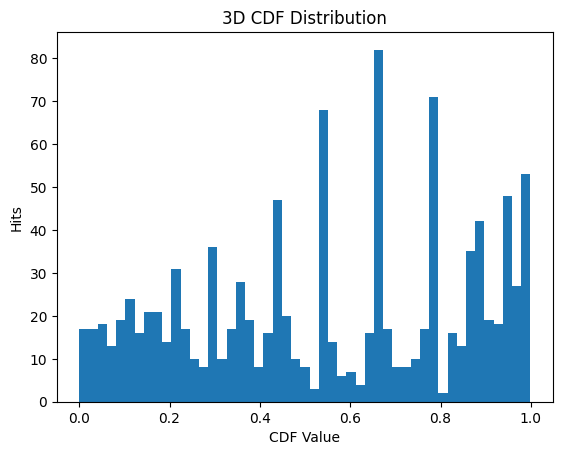

In [ ]:
cdf(np.array([-125.545, 719.033, -311.44, 2.31525, 1.0098]), EventDataSampled)

In [ ]:
best_fit = minimizer(np.array([632.878,-456.534,-261.346, 0.938481, 2.22391,0]), EventData2)
cdf(best_fit['x'], EventData2)

KeyboardInterrupt: 

In [ ]:
def sample_dt(dr, dphi):
    pvalues = []
    spline=splinefit_3d 
    t = np.linspace(spline.extents[-1][0], spline.extents[-1][1], 2000)
    pdf = evalPdf(spline, dr, dphi, t)
    for dt in t:
        cdf = np.sum(pdf[:np.searchsorted(t, dt)])/np.sum(pdf)
        pvalues.append(cdf)
    return t, pvalues

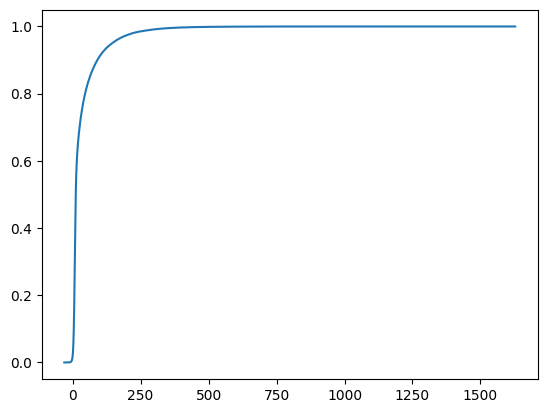

In [ ]:
t, p = sample_dt(100, 0)
plt.plot(t, p)

In [ ]:
ary1 = np.array([1,2,3])
ary2 = np.array([4,5,6])
stacked = np.column_stack([ary1, ary2])
print(stacked)
for i in range(len(stacked)):
    print(stacked[i,1])

[[1 4]
 [2 5]
 [3 6]]
4
5
6
